## Модель для предварительного одобрения кредитного продукта

[ссылка на соревнование от Тинькофф](https://www.kaggle.com/competitions/fintech-credit-scoring/overview)

Задача: Для построения модели кредитного скоринга (предварительное одобрение кредитной карты при заполнении онлайн-анекты на сайте банка), нужно отобрать 5-10 признаков. Признаки должны быть простыми в понимании (пользователь должен без труда заполнить анкету, поэтому вопросы должны касаться непосредственно клиента и не содержать специализированную информацию, которую о нем собирают финансовые организации)

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import phik
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from plot_countplots import plot_countplots
import warnings

from catboost import CatBoostClassifier, cv, Pool
from sklearn.feature_selection import GenericUnivariateSelect, mutual_info_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_auc_score, 
                             PrecisionRecallDisplay, classification_report,
                             precision_score, recall_score)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import joblib

In [2]:
RANDOM_STATE = 4242
TEST_SIZE = 0.3
sns.set(rc={'figure.figsize' : (10, 6)})
sns.set(style='darkgrid')


In [3]:
warnings.filterwarnings('ignore')

### Загрузка данных

In [4]:
# Загрузим данные из файла
application_info = pd.read_csv("data/application_info.csv")
application_info.head()

,id,application_dt,sample_cd,education_cd,gender_cd,age,car_own_flg,car_type_flg,appl_rej_cnt,good_work_flg,Score_bki,out_request_cnt,region_rating,home_address_cd,work_address_cd,income,SNA,first_time_cd,Air_flg
0,1,01JAN2014,train,SCH,M,27,Y,Y,0,0,-1.917831,0,40,2,3,32000,1,4,N
1,2,01JAN2014,train,GRD,F,26,N,N,0,0,-1.153144,2,60,2,3,50000,2,1,N
2,3,01JAN2014,train,SCH,M,35,N,N,0,1,-1.732810,0,40,1,2,20000,4,3,N
3,4,01JAN2014,train,GRD,F,35,N,N,0,1,-2.552133,2,20,2,3,80000,1,3,N
4,5,01JAN2014,train,UGR,F,24,N,N,0,0,-1.914581,1,50,2,3,27000,1,2,N


In [5]:
# Посмотрим общую информацию о данных
application_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205296 entries, 0 to 205295
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               205296 non-null  int64  
 1   application_dt   205296 non-null  object 
 2   sample_cd        205296 non-null  object 
 3   education_cd     204384 non-null  object 
 4   gender_cd        205296 non-null  object 
 5   age              205296 non-null  int64  
 6   car_own_flg      205296 non-null  object 
 7   car_type_flg     205296 non-null  object 
 8   appl_rej_cnt     205296 non-null  int64  
 9   good_work_flg    205296 non-null  int64  
 10  Score_bki        205296 non-null  float64
 11  out_request_cnt  205296 non-null  int64  
 12  region_rating    205296 non-null  int64  
 13  home_address_cd  205296 non-null  int64  
 14  work_address_cd  205296 non-null  int64  
 15  income           205296 non-null  int64  
 16  SNA              205296 non-null  int6

Можно заметить пропуски в столбце `education_cd`. Типы данных в колонках указаны верно.

In [6]:
# Проверим данные на полные дубликаты
application_info.duplicated().sum()

np.int64(0)

In [7]:
# Посмотрим на категориальные признаки
for i in application_info.drop('application_dt', axis=1).select_dtypes(exclude='number'):
    print(f'Колонка {i} содержит уникальные значения: {application_info[i].unique()}')

Колонка sample_cd содержит уникальные значения: ['train' 'validate' 'test']
Колонка education_cd содержит уникальные значения: ['SCH' 'GRD' 'UGR' 'PGR' 'ACD' nan]
Колонка gender_cd содержит уникальные значения: ['M' 'F']
Колонка car_own_flg содержит уникальные значения: ['Y' 'N']
Колонка car_type_flg содержит уникальные значения: ['Y' 'N']
Колонка Air_flg содержит уникальные значения: ['N' 'Y']


In [8]:
# Посмотрим на статистическую информацию числовых признаков
application_info.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
id,205296.0,102648.500000,59263.994769,1.000000,51324.750000,102648.500000,153972.250000,205296.000000
age,205296.0,39.354566,11.451011,21.000000,30.000000,37.000000,48.000000,72.000000
appl_rej_cnt,205296.0,0.277297,0.782794,0.000000,0.000000,0.000000,0.000000,33.000000
good_work_flg,205296.0,0.169701,0.375371,0.000000,0.000000,0.000000,0.000000,1.000000
Score_bki,205296.0,-1.967120,0.488055,-3.624586,-2.313894,-1.990599,-1.641914,0.199773
out_request_cnt,205296.0,2.015826,2.138564,0.000000,1.000000,2.000000,3.000000,53.000000
region_rating,205296.0,57.332340,13.262627,20.000000,50.000000,50.000000,70.000000,80.000000
home_address_cd,205296.0,1.602218,0.520577,1.000000,1.000000,2.000000,2.000000,3.000000
work_address_cd,205296.0,2.520210,0.689453,1.000000,2.000000,3.000000,3.000000,3.000000
income,205296.0,42251.807610,45183.110679,1000.000000,20000.000000,30000.000000,50000.000000,1000000.000000


Возраст от 21 года до 72 лет, максимальный доход 1_000_000, максимальное кол-во отказов в кредите одному клиенту составляет 33 раза, максимальное кол-во запросов в бюро - 53

In [9]:
# Посмотрим на кол-во заявителей с доходом свыше 100_000
application_info.query('income > 100_000').shape[0]

9439

In [10]:
# Посмотрим на статистическую информацию категориальных признаков
application_info.select_dtypes(exclude='number').describe().T

,count,unique,top,freq
application_dt,205296,333,18MAR2014,1491
sample_cd,205296,3,train,110148
education_cd,204384,5,SCH,100234
gender_cd,205296,2,F,117400
car_own_flg,205296,2,N,139119
car_type_flg,205296,2,N,166471
Air_flg,205296,2,N,172168


In [11]:
# Посмотрим на распределение значений в столбце `education_cd`
application_info.education_cd.value_counts(dropna=False, normalize=True)

education_cd
SCH    0.488241
GRD    0.347873
UGR    0.137772
PGR    0.018710
NaN    0.004442
ACD    0.002962
Name: proportion, dtype: float64

In [12]:
# Заполним пропуски. Пропуски в данных могут означать заявителей без образования
application_info['education_cd'] = application_info['education_cd'].fillna("without_education")

In [13]:
application_info.isna().sum()

id                 0
application_dt     0
sample_cd          0
education_cd       0
gender_cd          0
age                0
car_own_flg        0
car_type_flg       0
appl_rej_cnt       0
good_work_flg      0
Score_bki          0
out_request_cnt    0
region_rating      0
home_address_cd    0
work_address_cd    0
income             0
SNA                0
first_time_cd      0
Air_flg            0
dtype: int64

In [14]:
# Приведем бинарные признаки к виду {No:0, Yes:1}
# for i in data[["car_own_flg", "car_type_flg", "Air_flg"]]:
#     data[i] = data[i].map({'N': 0, 'Y': 1})
# data['good_work_flg'] = data['good_work_flg'].map({0: 'N', 1: 'Y'})

In [15]:
# Загрузим данные из файла
target = pd.read_csv("data/default_flg.csv")

In [16]:
# Посмотрим на данные
target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180816 entries, 0 to 180815
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   id           180816 non-null  int64
 1   default_flg  180816 non-null  int64
dtypes: int64(2)
memory usage: 2.8 MB


In [17]:
# Присоединим целевую переменную
df = application_info.merge(target, how='right', on='id')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180816 entries, 0 to 180815
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               180816 non-null  int64  
 1   application_dt   180816 non-null  object 
 2   sample_cd        180816 non-null  object 
 3   education_cd     180816 non-null  object 
 4   gender_cd        180816 non-null  object 
 5   age              180816 non-null  int64  
 6   car_own_flg      180816 non-null  object 
 7   car_type_flg     180816 non-null  object 
 8   appl_rej_cnt     180816 non-null  int64  
 9   good_work_flg    180816 non-null  int64  
 10  Score_bki        180816 non-null  float64
 11  out_request_cnt  180816 non-null  int64  
 12  region_rating    180816 non-null  int64  
 13  home_address_cd  180816 non-null  int64  
 14  work_address_cd  180816 non-null  int64  
 15  income           180816 non-null  int64  
 16  SNA              180816 non-null  int6

In [19]:
# Проверим данные на полные дубликаты
df.duplicated().sum()

np.int64(0)

### EDA

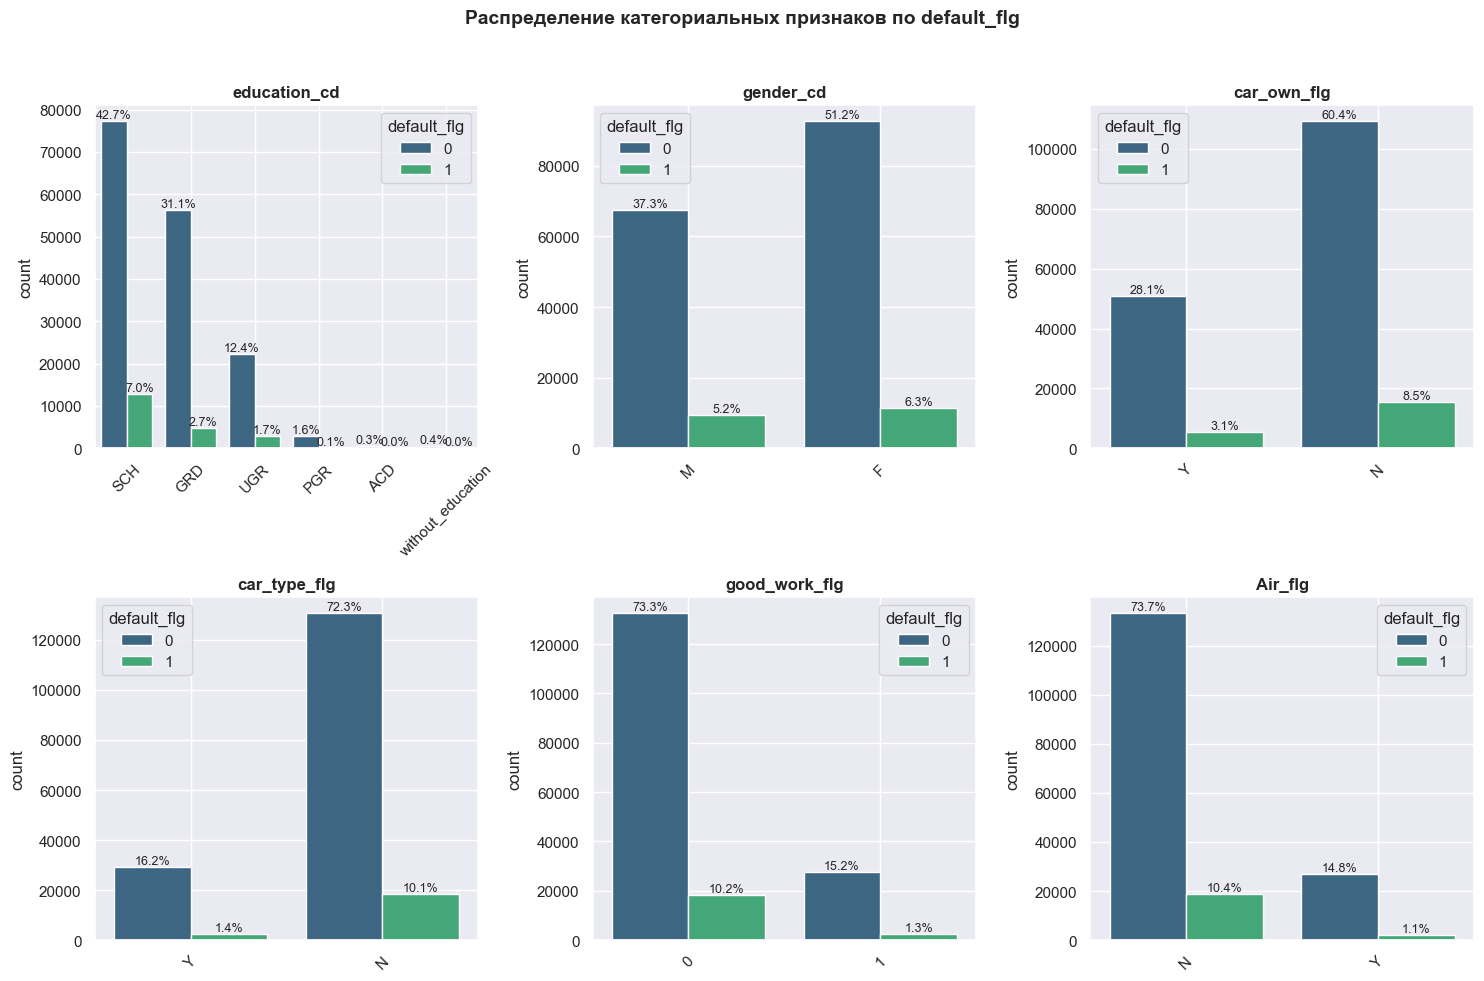

In [20]:
plot_countplots(df, 
                ['education_cd', 
                 'gender_cd', 
                 'car_own_flg', 
                 'car_type_flg', 
                 'good_work_flg', 
                 'Air_flg'], 
                 'default_flg')

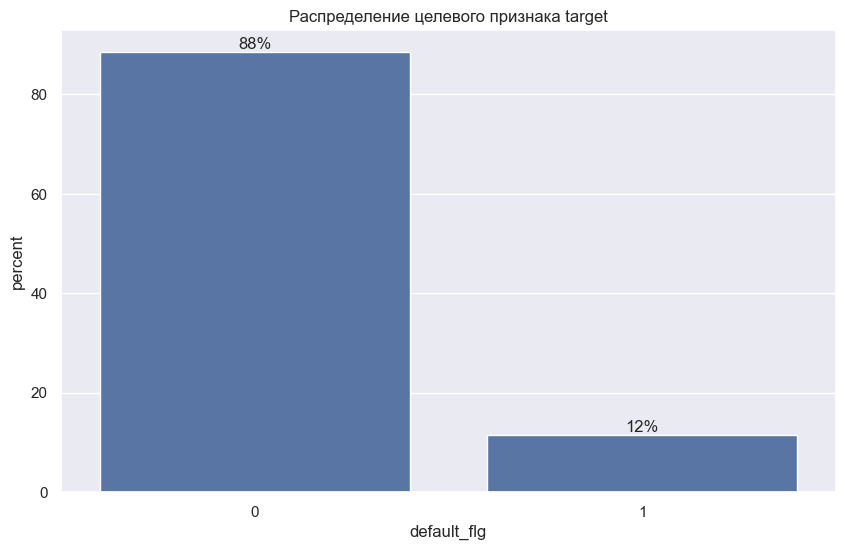

In [21]:
ax = sns.countplot(data=df, x='default_flg', stat='percent')

for cont in ax.containers:
    ax.bar_label(cont, fmt='%.0f%%')
plt.title(f'Распределение целевого признака target')
plt.show()

Классы целевого признака не сбалансированы

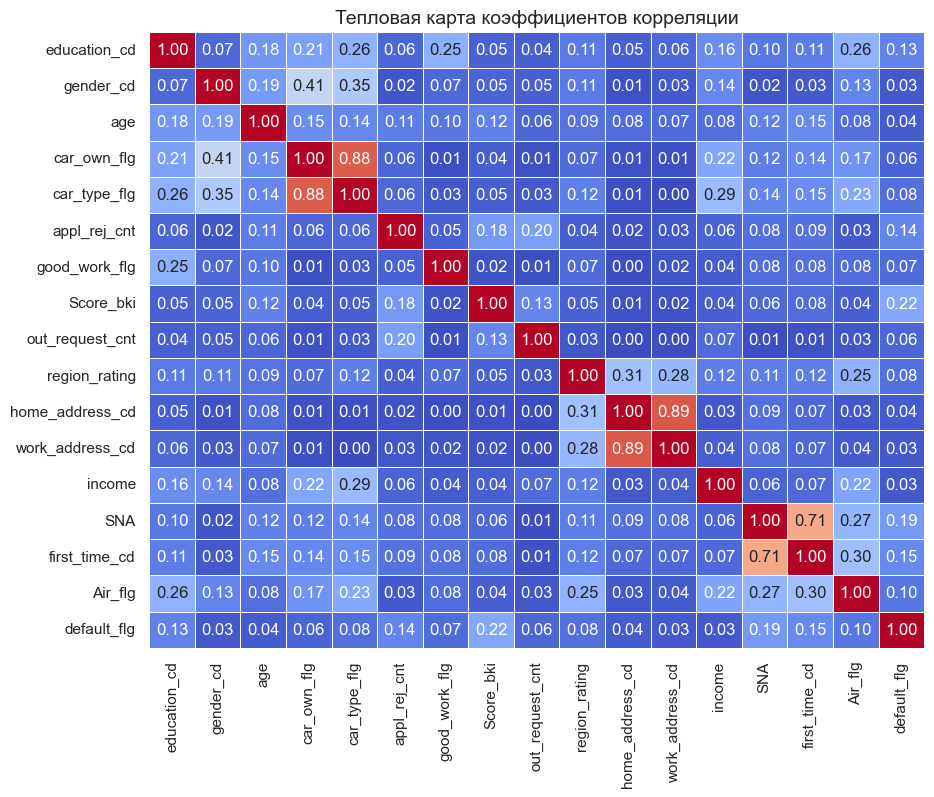

In [22]:
# Вычисление матрицы корреляции с использованием phik 
# Построим тепловую карту коэффициентов корреляции рассчитаных с использованием phik 
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(['id', 'application_dt', 'sample_cd'], axis=1).
            phik_matrix(interval_cols = ['income', 'age', 'region_rating', 'aapl_rej_cnt', 'Score_bki', 'out_request_cnt']), 
            annot=True, fmt=".2f", cmap='coolwarm', cbar=False, linewidths=0.5)
plt.title('Тепловая карта коэффициентов корреляции', fontsize=14)
plt.show()

### Подготовка данных к обучению

In [23]:
# Разбиваем данные на тренировочную и тестовую выборки
X_train = df.query('sample_cd == "train"').drop(['id', 'application_dt', 'sample_cd', 'default_flg'], axis=1)
X_test = df.query('sample_cd == "validate"').drop(['id', 'application_dt', 'sample_cd', 'default_flg'], axis=1)
y_train = df.query('sample_cd == "train"')['default_flg']
y_test = df.query('sample_cd == "validate"')['default_flg']

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((110148, 16), (70668, 16), (110148,), (70668,))

In [24]:
# Разбиваем данные на тренировочную и тестовую выборки
# X_train, X_test, y_train, y_test = train_test_split(df.drop(['id', 'default_flg'], axis=1),
#                                                     df['default_flg'],
#                                                     test_size=TEST_SIZE,
#                                                     random_state=RANDOM_STATE, 
#                                                     stratify = df['default_flg']
# )

# X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [25]:
# Выделим количественные признаки
num_columns = ['age', 'appl_rej_cnt', 'Score_bki', 'out_request_cnt', 'region_rating', 'home_address_cd',
                'work_address_cd', 'SNA', 'first_time_cd', 'income']
# Выделим категориальные признаки
ohe_columns = X_train.select_dtypes(exclude='number').columns.tolist()
ohe_columns

['education_cd', 'gender_cd', 'car_own_flg', 'car_type_flg', 'Air_flg']

In [26]:
# Пайплайн для подготовки категориальных признаков
ohe_pipe = Pipeline(
    [('simpleImputer', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

In [27]:
# Общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('num', StandardScaler(), num_columns) 
    ],
    remainder='passthrough'
)

In [28]:
X_train_pre = data_preprocessor.fit_transform(X_train)
X_test_pre = data_preprocessor.transform(X_test)

### LogisticRegression

In [29]:
pipe_lr= Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE)) # Целевой признак несбалансирован, поэтом добавляем гиперпараметр class_weight="balanced"
    ]
)

pipe_lr.fit(X_train, y_train) 
print(f'Метрика roc_auc на трейне: {roc_auc_score(y_train, pipe_lr.predict_proba(X_train)[:, 1])}')
print(f'Метрика precision на трейне: {precision_score(y_train, pipe_lr.predict(X_train))}')
print(f'Метрика recall на трейне: {recall_score(y_train, pipe_lr.predict(X_train))}')

Метрика roc_auc на трейне: 0.7293603306352598
Метрика precision на трейне: 0.22500060283089388
Метрика recall на трейне: 0.6682182755657404


In [30]:
results = pd.DataFrame(columns=['model', 'roc_auc'])
results.loc[len(results)] = ['LinearRegression', 
                             roc_auc_score(y_train, pipe_lr.predict_proba(X_train)[:, 1])]
results

,model,roc_auc
0,LinearRegression,0.72936


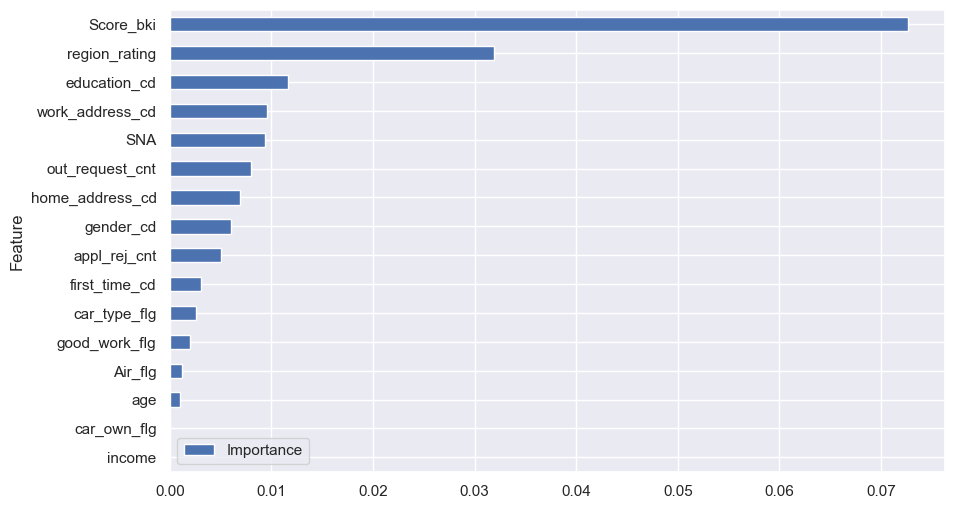

In [31]:
# Посмотрим на значимость признаков для модели
result = permutation_importance(pipe_lr, X_train, y_train, scoring='roc_auc')

feature_importance = pd.DataFrame({'Feature': X_train.columns.tolist(), 'Importance': result['importances_mean']})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6));

#### LogisticRegression без нормализации числовых признаков

In [32]:
# Пайплайн для подготовки категориальных признаков
ohe_pipe_1 = Pipeline(
    [('simpleImputer', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

In [33]:
# Общий пайплайн для подготовки данных
data_preprocessor_1 = ColumnTransformer(
    [('ohe', ohe_pipe_1, ohe_columns)
    ],
    remainder='passthrough'
)

In [34]:
pipe_lr_1= Pipeline(
    [
        ('preprocessor', data_preprocessor_1),
        ('models', LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE))
    ]
)

pipe_lr_1.fit(X_train, y_train) 
print(f'Метрика roc_auc на трейне: {roc_auc_score(y_train, pipe_lr_1.predict_proba(X_train)[:, 1])}')
print(f'Метрика precision на трейне: {precision_score(y_train, pipe_lr_1.predict(X_train))}')
print(f'Метрика recall на трейне: {recall_score(y_train, pipe_lr_1.predict(X_train))}')

Метрика roc_auc на трейне: 0.6684341396954414
Метрика precision на трейне: 0.19935342105927817
Метрика recall на трейне: 0.5652391864795188


Модель **LogisticRegression** показывает хуже результат при ненормализованных числовых признаках

#### LogisticRegression с кросс-валидацией

In [35]:
pipe_lr= Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE)) # Целевой признак несбалансирован, поэтом добавляем гиперпараметр class_weight="balanced"
    ]
)

cross_val_score(pipe_lr, X_train, y_train, cv=StratifiedKFold(), scoring='roc_auc')
# print(f'Метрика roc_auc на трейне: {roc_auc_score(y_train, pipe_lr.predict_proba(X_train)[:, 1])}')
# print(f'Метрика precision на трейне: {precision_score(y_train, pipe_lr.predict(X_train))}')
# print(f'Метрика recall на трейне: {recall_score(y_train, pipe_lr.predict(X_train))}')

array([0.72519224, 0.73860198, 0.72694167, 0.72426603, 0.72508193])

Модель logisticregression на кросс-валидации показывает такой же результат

#### LogisticRegression c подбором гиперпараметров и кросс-валидацией

In [36]:
pipe_lr_1= Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE)) # Целевой признак несбалансирован, поэтом добавляем гиперпараметр class_weight="balanced"
    ]
)

In [37]:
param_grid_lr = [
    {
        'models__penalty': ['l2', None],
        'models__C': [0.01, 0.05, 0.1, 0.5]
    }
]

In [38]:
gs_lr = GridSearchCV(
    pipe_lr_1, 
    param_grid_lr, 
    cv=StratifiedKFold(), 
    n_jobs=-1, 
    error_score='raise', 
    scoring='roc_auc')

gs_lr.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         Pipeline(steps=[('simpleImputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=Fal...
                                                                          'Air_flg']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'appl_rej_cnt',
                                                                          'Score_bki',
                                                                          'out_request_cnt',
                                                                          'region_rating',
                                                                          'home_address_cd',
                                                                          'work_address_cd',
                                                                          'SNA',
                                                                          'first_time_cd',
                                                                          'income'])])),
                                       ('models',
                                        LogisticRegression(class_weight='balanced',
                                                           random_state=4242))]),
             n_jobs=-1,
             param_grid=[{'models__C': [0.01, 0.05, 0.1, 0.5],
                          'models__penalty': ['l2', None]}],
             scoring='roc_auc')

In [39]:
gs_lr.best_params_, gs_lr.best_score_

({'models__C': 0.01, 'models__penalty': 'l2'}, np.float64(0.7280571357372436))

Подбор гиперпараметров не улучшил метрику на тренировочных данных

### RandomForestClassifier

In [40]:
pipe_rf= Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)) # Целевой признак несбалансирован, поэтом добавляем гиперпараметр class_weight="balanced"
    ]
)
cross_val_score(pipe_rf, X_train, y_train, cv=StratifiedKFold(), scoring='roc_auc').mean()

# print(f'Метрика roc_auc на трейне: {roc_auc_score(y_train, pipe_rf.predict_proba(X_train)[:, 1])}')
# print(f'Метрика precision на трейне: {precision_score(y_train, pipe_rf.predict(X_train))}')
# print(f'Метрика recall на трейне: {recall_score(y_train, pipe_rf.predict(X_train))}')

np.float64(0.6997559121847455)

In [41]:
pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['education_cd', 'gender_cd',
                                                   'car_own_flg',
                                                   'car_type_flg', 'Air_flg']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'appl_rej_cnt',
                                                   'Score_bki',
                                                   'out_request_cnt',
                                                   'region_rating',
                                                   'home_address_cd',
                                                   'work_address_cd', 'SNA',
                                                   'first_time_cd',
                                                   'income'])])),
                ('models',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=4242))])

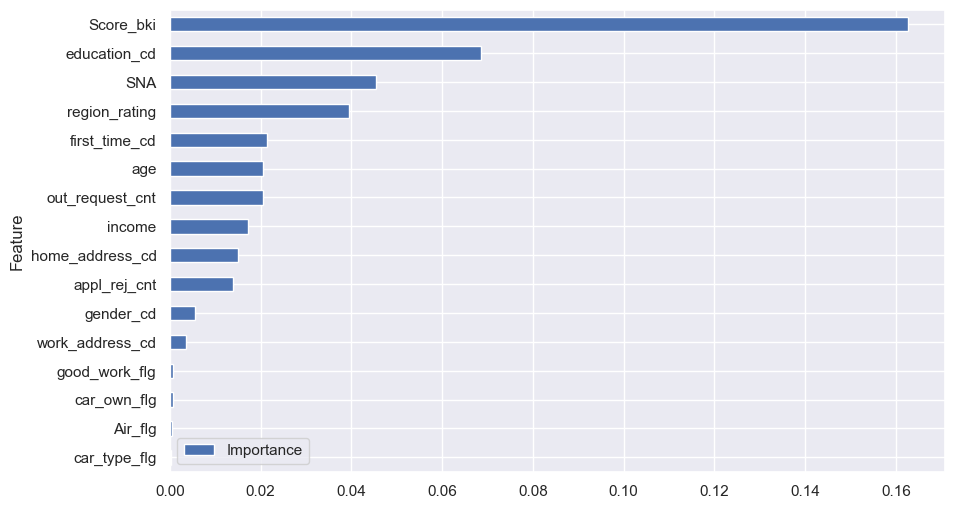

In [42]:
# Посмотрим на значимость признаков для модели
result = permutation_importance(pipe_rf, X_train, y_train, scoring='roc_auc')

feature_importance = pd.DataFrame({'Feature': X_train.columns.tolist(), 'Importance': result['importances_mean']})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6));

Модель в базовом исполнении на кросс-валидации показывает хуже результат чем, модель Логистической Регрессии

In [43]:
results.loc[len(results)] = ['RandomForestClassifier', 
                             cross_val_score(pipe_rf, X_train, y_train, cv=StratifiedKFold(), scoring='roc_auc').mean()]
results

,model,roc_auc
0,LinearRegression,0.729360
1,RandomForestClassifier,0.699756


### CatBoostClassifier

In [44]:
pool = Pool(X_train, y_train, cat_features=ohe_columns)
pool_test = Pool(X_test, y_test, cat_features=ohe_columns)

In [45]:
catboost = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    scale_pos_weight=7.0,
    random_state=RANDOM_STATE,
    verbose=False)

In [46]:
catboost.fit(pool)

print(f'Метрика roc_auc на трейне: {roc_auc_score(y_train, catboost.predict_proba(X_train)[:, 1])}')
print(f'Метрика precision на трейне: {precision_score(y_train, catboost.predict(X_train))}')
print(f'Метрика recall на трейне: {recall_score(y_train, catboost.predict(X_train))}')

Метрика roc_auc на трейне: 0.8120146143194988
Метрика precision на трейне: 0.26876134758926773
Метрика recall на трейне: 0.7632483529074764


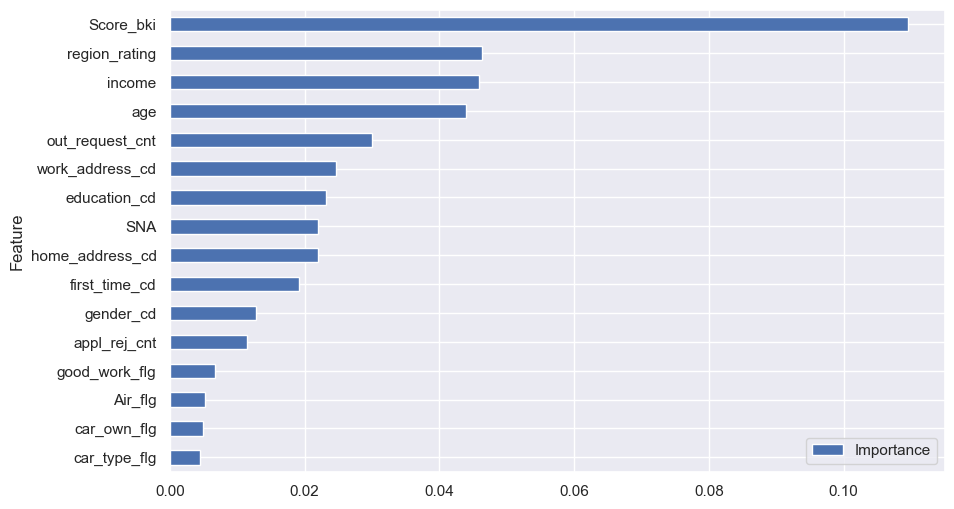

In [47]:
# Посмотрим на значимость признаков для модели
result = permutation_importance(catboost, X_train, y_train, scoring='roc_auc')

feature_importance = pd.DataFrame({'Feature': X_train.columns.tolist(), 'Importance': result['importances_mean']})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6));

In [48]:
results.loc[len(results)] = ['CatBoostClassifier', 
                             roc_auc_score(y_train, catboost.predict_proba(X_train)[:, 1])]
results

,model,roc_auc
0,LinearRegression,0.729360
1,RandomForestClassifier,0.699756
2,CatBoostClassifier,0.812015


In [49]:
# Рассчитаем метрики для оценки модели на тестовых данных
y_pred = catboost.predict(X_test)

print(f'Метрика roc_auc на тесте: {roc_auc_score(y_test, catboost.predict_proba(X_test)[:, 1])}')
print(f'Метрика precision на тесте: {precision_score(y_test, y_pred)}')
print(f'Метрика recall на тесте: {recall_score(y_test, y_pred)}')

Метрика roc_auc на тесте: 0.714422100449595
Метрика precision на тесте: 0.17192386394347708
Метрика recall на тесте: 0.6481804949053858


Отмечается значительное падение метрики на тестовых данных

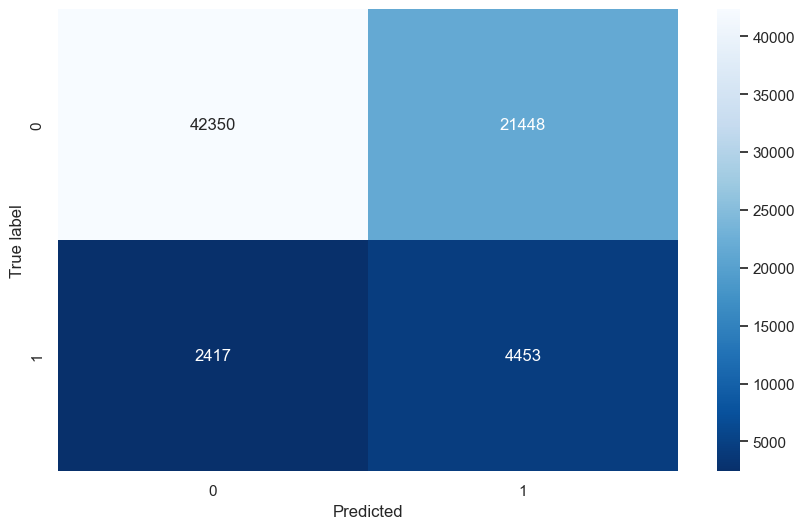

In [50]:
# Построим матрицу ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('True label')
plt.xlabel('Predicted');

In [51]:
# Оценим точность лучшей модели
pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T

,precision,recall,f1-score,support
0,0.946009,0.663814,0.780178,63798.000000
1,0.171924,0.648180,0.271765,6870.000000
accuracy,0.662294,0.662294,0.662294,0.662294
macro avg,0.558967,0.655997,0.525971,70668.000000
weighted avg,0.870757,0.662294,0.730752,70668.000000


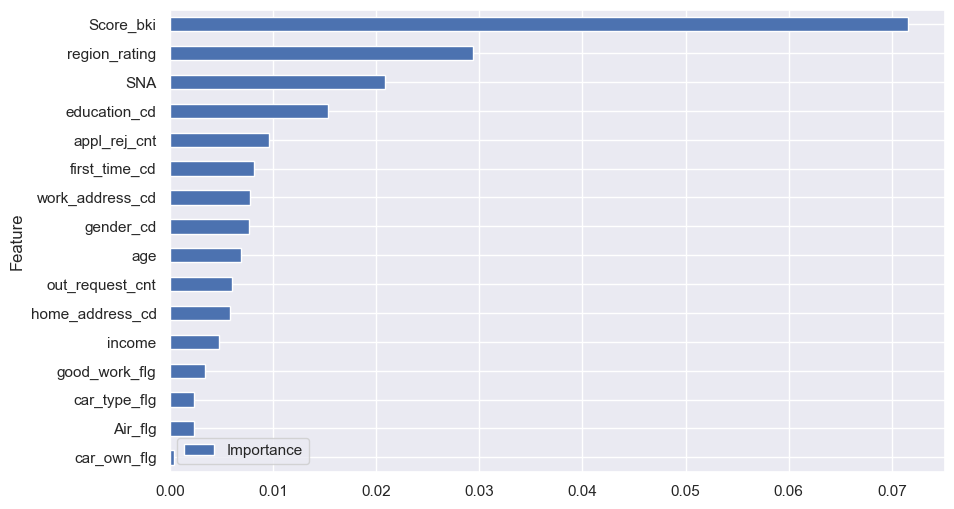

In [52]:
# Посмотрим на значимость признаков для модели
result = permutation_importance(catboost, X_test, y_test, scoring='roc_auc')

feature_importance = pd.DataFrame({'Feature': X_train.columns.tolist(), 'Importance': result['importances_mean']})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6));

#### CatBoostClassifier с подбором гиперпараметров

In [53]:
pipe_cb= Pipeline(
    [('preprocessor', data_preprocessor),
     ('models', catboost)] 
)

In [54]:
param_grid_cb = [
    {
        'models__learning_rate': [0.03, 0.07, 0.1, 0.2],
        'models__depth': [2, 4, 6, 8],
        'models__iterations': [200, 400, 600, 800]
    }
]

In [55]:
rs_cb = RandomizedSearchCV(pipe_cb,
                        param_grid_cb,
                        n_iter=30,
                        cv=StratifiedKFold(),
                        n_jobs=-1,
                        error_score='raise',
                        scoring='roc_auc',
                        random_state=RANDOM_STATE)

rs_cb.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                   error_score='raise',
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore',
                                                                                                              sparse_outp...
                                                                                'SNA',
                                                                                'first_time_cd',
                                                                                'income'])])),
                                             ('models',
                                              CatBoostClassifier(eval_metric='AUC', loss_function='Logloss', random_state=4242, scale_pos_weight=7.0, verbose=False))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions=[{'models__depth': [2, 4, 6, 8],
                                         'models__iterations': [200, 400, 600,
                                                                800],
                                         'models__learning_rate': [0.03, 0.07,
                                                                   0.1, 0.2]}],
                   random_state=4242, scoring='roc_auc')

In [56]:
rs_cb.best_params_, rs_cb.best_score_

({'models__learning_rate': 0.03,
  'models__iterations': 800,
  'models__depth': 4},
 np.float64(0.7348289181836984))

### Упрощенная модель для веб-сервиса

In [57]:
data = df[['income', 'age', 'car_own_flg', 'good_work_flg', 'default_flg']]

In [58]:
data['car_own_flg'] = data['car_own_flg'].map({'N': 0, 'Y': 1})

In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180816 entries, 0 to 180815
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   income         180816 non-null  int64
 1   age            180816 non-null  int64
 2   car_own_flg    180816 non-null  int64
 3   good_work_flg  180816 non-null  int64
 4   default_flg    180816 non-null  int64
dtypes: int64(5)
memory usage: 6.9 MB


In [60]:
data.to_csv('data/final_data.csv', index=False, encoding='utf-8')

In [68]:
# Разбиваем данные на тренировочную и тестовую выборки
X_tr, X_ts, y_tr, y_ts = train_test_split(data.drop('default_flg', axis=1),
                                                    data['default_flg'],
                                                    test_size=TEST_SIZE,
                                                    random_state=RANDOM_STATE, 
                                                    stratify = df['default_flg']
)

X_tr.shape, X_ts.shape, y_tr.shape, y_ts.shape

((126571, 4), (54245, 4), (126571,), (54245,))

**LogisticRegression**

In [70]:
# Логистическая регрессия
lr = LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE) # Целевой признак несбалансирован, поэтом добавляем гиперпараметр class_weight="balanced"

lr.fit(X_tr, y_tr) 
print(f'Метрика roc_auc на трейне: {roc_auc_score(y_tr, lr.predict_proba(X_tr)[:, 1])}')
print(f'Метрика precision на трейне: {precision_score(y_tr, lr.predict(X_tr))}')
print(f'Метрика recall на трейне: {recall_score(y_tr, lr.predict(X_tr))}')

Метрика roc_auc на трейне: 0.571150387131811
Метрика precision на трейне: 0.13259749229624906
Метрика recall на трейне: 0.6845172792100932


In [71]:
print(f'Метрика roc_auc на тесте: {roc_auc_score(y_ts, lr.predict_proba(X_ts)[:, 1])}')
print(f'Метрика precision на тесте: {precision_score(y_ts, lr.predict(X_ts))}')
print(f'Метрика recall на тесте: {recall_score(y_ts, lr.predict(X_ts))}')

Метрика roc_auc на тесте: 0.5691914524429628
Метрика precision на тесте: 0.13236658215323727
Метрика recall на тесте: 0.68496


In [72]:
# Сохраним модель
joblib.dump(lr, "model.pkl")

['model.pkl']